# Data Pre-Processing

#### Import Packages and CSV

In [1]:
#!pip install mlflow daghshub xgboost catboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import mlflow
from sklearn.model_selection import train_test_split
import mlflow.sklearn
import dagshub
warnings.filterwarnings("ignore")
pd.pandas.set_option("display.max_columns", None)
# Create Dataframe
raw_df= pd.read_csv("EasyVisa.csv")
# Print shape of dataset
print(raw_df.shape)

C:\Users\Hariprasad\anaconda3\Lib\site-packages\mlflow\protos\service_pb2.py:11: UserWarning: google.protobuf.service module is deprecated. RPC implementations should provide code generator plugins which generate code specific to the RPC implementation. service.py will be removed in Jan 2025
  from google.protobuf import service as _service


(25480, 12)


In [3]:
train_df, test_df = train_test_split(raw_df, test_size=0.2, random_state=42)

In [4]:
#mlflow.set_tracking_uri("https://dagshub.com/kalehariprasad/Visa-approval-prediction.mlflow")
mlflow.set_tracking_uri("http://ec2-3-89-120-212.compute-1.amazonaws.com:5000/")
#dagshub.init(repo_owner='kalehariprasad', repo_name='Visa-approval-prediction', mlflow=True)


## Data Cleaning

### Handling Missing values

* Handling Missing values 
* Handling Duplicates
* Check data type
* Understand the dataset

#### Check Null Values

In [5]:
##these are the features with nan value
features_with_na=[features for features in train_df.columns if train_df[features].isnull().sum()>=1]
for feature in features_with_na:
    print(feature,np.round(df[feature].isnull().mean()*100,5), '% missing values')

In [6]:
features_with_na

[]

* **There are no null values in the dataset**

### 3.2 Other Data Cleaning steps

**Handling Duplicates**

In [7]:
train_df.duplicated().sum()

0

* **No Duplicates in the dataset**

**Remove case_id from the dataset as it cannot used in Model Training**

In [8]:
train_df.drop('case_id', inplace=True, axis=1)

# Feature Engineering

## Feature Extraction

In [9]:
train_df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
2403,Asia,High School,Y,Y,1411,2009,West,75107.37,Year,Y,Denied
6830,North America,Master's,Y,N,781,2012,West,102403.56,Year,Y,Denied
878,Asia,High School,Y,N,958,2005,South,89991.95,Year,Y,Certified
24061,Asia,Master's,N,N,900,1962,West,128104.61,Year,Y,Denied
2109,Europe,High School,N,N,3533,1993,West,12647.14,Year,Y,Denied


In [10]:
# importing date class from datetime module
from datetime import date
  
# creating the date object of today's date
todays_date = date.today()
current_year= todays_date.year

In [11]:
current_year

2025

**Subtract current year with year of estab to get company's age**

In [12]:
train_df['company_age'] = current_year-train_df['yr_of_estab']

In [13]:
train_df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
2403,Asia,High School,Y,Y,1411,2009,West,75107.37,Year,Y,Denied,16
6830,North America,Master's,Y,N,781,2012,West,102403.56,Year,Y,Denied,13
878,Asia,High School,Y,N,958,2005,South,89991.95,Year,Y,Certified,20
24061,Asia,Master's,N,N,900,1962,West,128104.61,Year,Y,Denied,63
2109,Europe,High School,N,N,3533,1993,West,12647.14,Year,Y,Denied,32


In [14]:
train_df.drop('yr_of_estab', inplace=True, axis=1)

### Type of Features

**Numeric Features**

In [15]:
num_features = [feature for feature in train_df.columns if train_df[feature].dtype != 'O']
print('Num of Numerical Features :', len(num_features))

Num of Numerical Features : 3


**Categorical Features**

In [16]:
cat_features = [feature for feature in train_df.columns if train_df[feature].dtype == 'O']
print('Num of Categorical Features :', len(cat_features))

Num of Categorical Features : 8


**Discrete features**

In [17]:
discrete_features=[feature for feature in num_features if len(train_df[feature].unique())<=25]
print('Num of Discrete Features :',len(discrete_features))

Num of Discrete Features : 0


**Continues Features**

In [18]:
continuous_features=[feature for feature in num_features if feature not in discrete_features]
print('Num of Continuous Features :',len(continuous_features))

Num of Continuous Features : 3


### Split X and Y

* **Split Dataframe to X and y**
* **Here we set a variable X i.e, independent columns, and a variable y i.e, dependent column as the “Case_Status” column.**


In [19]:
X = train_df.drop('case_status', axis=1)
y = train_df['case_status']

In [20]:
y.head()

2403        Denied
6830        Denied
878      Certified
24061       Denied
2109        Denied
Name: case_status, dtype: object

**Manual encoding target column**

In [21]:
# If the target column has Denied it is encoded as 1 others as 0
y= np.where(y=='Denied', 1,0)

In [22]:
y

array([1, 1, 0, ..., 0, 0, 0])

## Feature Transformation

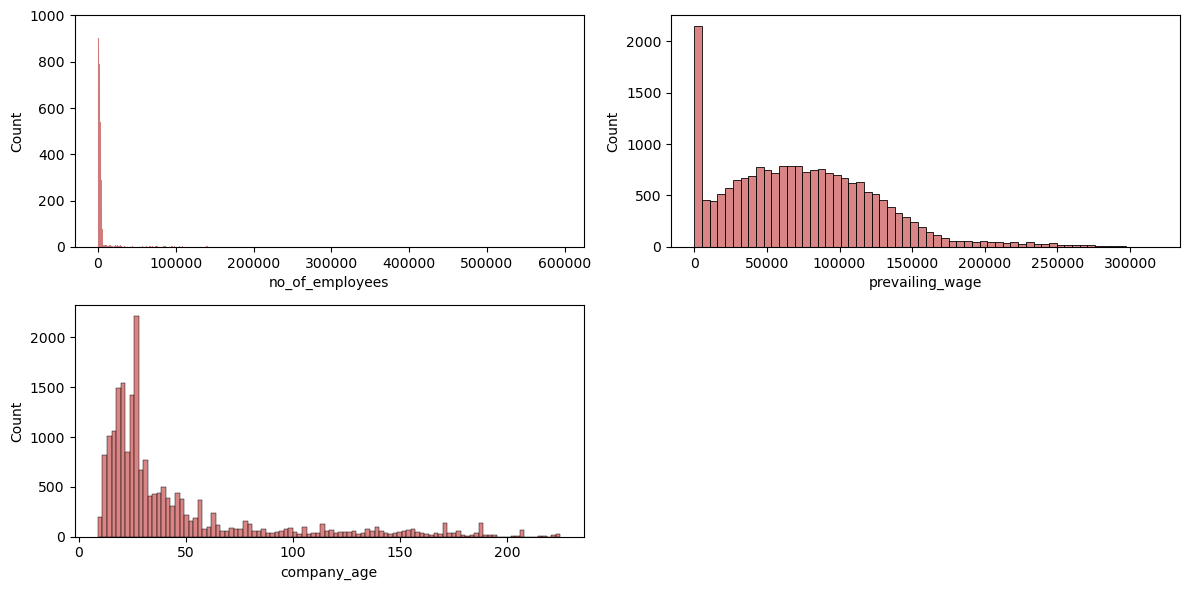

In [23]:
# distribution of data before scaling
plt.figure(figsize=(12, 6))
for i, col in enumerate(['no_of_employees','prevailing_wage','company_age']):
    plt.subplot(2, 2, i+1)
    sns.histplot(x=X[col], color='indianred')
    plt.xlabel(col)
    plt.tight_layout()

* No of employees and Copmany age column is skewed
* Apply a power transform featurewise to make data more Gaussian-like.

Power transforms are a family of parametric, monotonic transformations that are applied to make data more Gaussian-like. This is useful for modeling issues related to heteroscedasticity (non-constant variance), or other situations where normality is desired.

Currently, PowerTransformer supports the Box-Cox transform and the Yeo-Johnson transform.

**Checking Skewness**

**What is Skewness ?**

* Skewness refers to a distortion or asymmetry that deviates from the symmetrical bell curve, or normal distribution, in a set of data. If the curve is shifted to the left or to the right, it is said to be skewed. Skewness can be quantified as a representation of the extent to which a given distribution varies from a normal distribution. A normal distribution has a skew of zero

In [24]:
# Check Skewness
X[continuous_features].skew(axis=0, skipna=True)

no_of_employees    12.300118
prevailing_wage     0.741526
company_age         2.039380
dtype: float64

- Positiviely Skewed : company_age, no_of_employees.
- We can handle outliers and then check the skewness.

## Apply Power Transformer to Check if it can reduces the outliers

In [25]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
transform_features = ['company_age', 'no_of_employees']
X_copy = pt.fit_transform(X[transform_features])

In [26]:
X_copy = pd.DataFrame(X_copy, columns=transform_features)

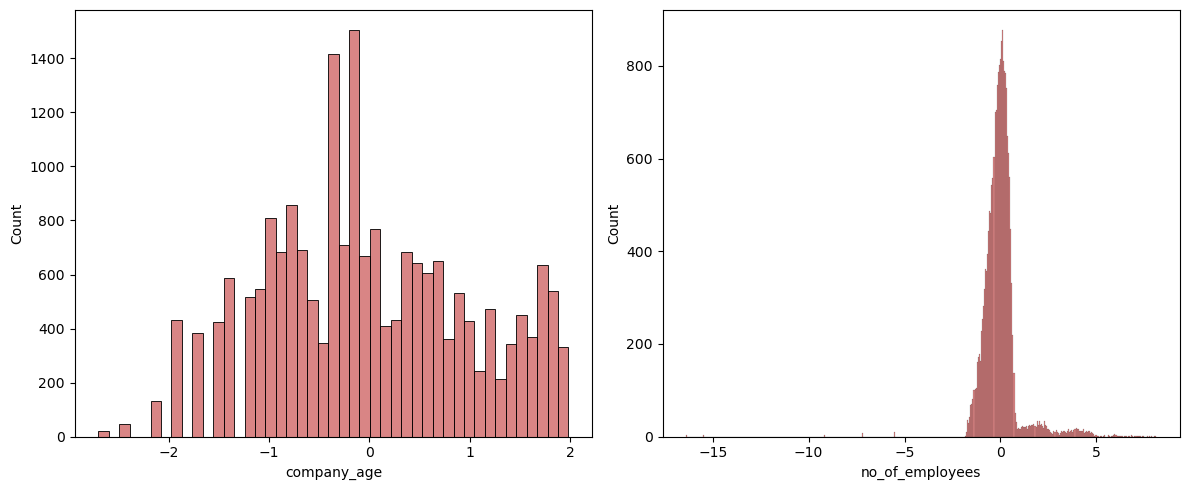

In [27]:
plt.figure(figsize=(12, 5))
for i, col in enumerate(transform_features):
    plt.subplot(1, 2, i+1)
    sns.histplot(x=X_copy[col], color='indianred')
    plt.xlabel(col)
    plt.tight_layout()

**Checking Skewness**

In [28]:
X_copy.skew(axis=0, skipna=True)

company_age        0.113702
no_of_employees    0.354011
dtype: float64

- Here Yeo-Johnson is used and it supports both positive or negative data for transformation.
- So Power Transformer with yeo-johnson can be used.

In [29]:
for feature in cat_features:
    print(feature,':', train_df[feature].nunique())

continent : 6
education_of_employee : 4
has_job_experience : 2
requires_job_training : 2
region_of_employment : 5
unit_of_wage : 4
full_time_position : 2
case_status : 2


## Feature Encoding and Scaling

 **One Hot Encoding for Columns which had lesser unique values and not ordinal**
* One hot encoding is a process by which categorical variables are converted into a form that could be provided to ML algorithms to do a better job in prediction.

**Ordinal Encoding for Columns which has many unique categories** 
* Ordinal encoding is used here as label encoder is supported for column transformer.
* Ordinal encoding is used for Ordinal Variable. Variable comprises a finite set of discrete values with a ranked ordering between values.

**Standard Scaler** 
* Standardize features by removing the mean and scaling to unit variance.

**Power Transformer**
* Power transforms are a technique for transforming numerical input or output variables to have a Gaussian or more-Gaussian-like probability distribution.

**Selecting number features for preprocessing**

In [30]:
num_features = list(X.select_dtypes(exclude="object").columns)

In [31]:
num_features

['no_of_employees', 'prevailing_wage', 'company_age']

### **Preprocessing using Column Transformer**

In [32]:
# Create Column Transformer with 3 types of transformers
or_columns = ['has_job_experience','requires_job_training','full_time_position','education_of_employee']
oh_columns = ['continent','unit_of_wage','region_of_employment']
transform_columns= ['no_of_employees','company_age']

from sklearn.preprocessing import OneHotEncoder, StandardScaler,OrdinalEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()
ordinal_encoder = OrdinalEncoder()

transform_pipe = Pipeline(steps=[
    ('transformer', PowerTransformer(method='yeo-johnson'))
])

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, oh_columns),
        ("Ordinal_Encoder", ordinal_encoder, or_columns),
        ("Transformer", transform_pipe, transform_columns),
        ("StandardScaler", numeric_transformer, num_features)
    ]
)

In [33]:
def prepare_test_data(test_df, preprocessor):
    """
    Prepares test data using an already-fitted preprocessor.

    Parameters:
    - test_df: DataFrame containing test data (must include 'yr_of_estab' and 'case_status')
    - preprocessor: A fitted ColumnTransformer from the training pipeline

    Returns:
    - X_test: Transformed feature matrix
    - y_test: Binary target array (1 if Denied, else 0)
    """

    df = test_df.copy()

    # Calculate current year
    todays_date = date.today()
    current_year= todays_date.year

    # Feature engineering: company_age
    df['company_age'] = current_year - df['yr_of_estab']
    df.drop('yr_of_estab', axis=1, inplace=True)

    # Split features and target
    X = df.drop('case_status', axis=1)
    y = np.where(df['case_status'] == 'Denied', 1, 0)

    # Apply transformation
    X_transformed = preprocessor.transform(X)

    return X_transformed, y


In [34]:
X = preprocessor.fit_transform(X)

# Classification

In [35]:

from imblearn.combine import SMOTETomek, SMOTEENN
# Resampling the minority class. The strategy can be changed as required.
smt = SMOTEENN(random_state=42,sampling_strategy='minority' )
# Fit the model to generate the data.
x_train, y_train = smt.fit_resample(X, y)

In [36]:
x_test, y_test = prepare_test_data(test_df, preprocessor)

In [37]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

In [38]:
def evaluate_clf(true, predicted):
    acc = accuracy_score(true, predicted) # Calculate Accuracy
    f1 = f1_score(true, predicted) # Calculate F1-score
    precision = precision_score(true, predicted) # Calculate Precision
    recall = recall_score(true, predicted)  # Calculate Recall
    roc_auc = roc_auc_score(true, predicted) #Calculate Roc
    return acc, f1 , precision, recall, roc_auc

In [39]:
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(),
    "K-Neighbors Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(), 
    "CatBoosting Classifier": CatBoostClassifier(verbose=False),
    "Support Vector Classifier": SVC(),
    "AdaBoost Classifier": AdaBoostClassifier()

}

In [40]:
import pandas as pd
import mlflow

def evaluate_models(x_train, x_test, y_train, y_test, models):
    '''
    Evaluates multiple models without hyperparameter tuning, logs results to MLflow,
    and returns a summary report.
    
    Args:
        x_train (pd.DataFrame): Training features
        x_test (pd.DataFrame): Test features
        y_train (pd.Series): Training labels
        y_test (pd.Series): Test labels
        models (dict): Dictionary of model_name: model_instance

    Returns:
        pd.DataFrame: Report with model name, accuracy, and AUC
    '''

    models_list = []
    accuracy_list = []
    auc_list = []

    mlflow.set_experiment("baseline model 2")

    with mlflow.start_run(run_name="all_models_evaluation") as parent_run:
        print("Parent Run ID:", parent_run.info.run_id)

        for model_name, model in models.items():
            with mlflow.start_run(run_name=model_name, nested=True):
                model.fit(x_train, y_train)

                # Make predictions
                y_train_pred = model.predict(x_train)
                y_test_pred = model.predict(x_test)

                # Training set performance
                train_acc, train_f1, train_precision, train_recall, train_auc = evaluate_clf(y_train, y_train_pred)
                mlflow.log_metric('model_train_accuracy', train_acc)
                mlflow.log_metric('model_train_f1', train_f1)
                mlflow.log_metric('model_train_precision', train_precision)
                mlflow.log_metric('model_train_recall', train_recall)
                mlflow.log_metric('model_train_rocauc_score', train_auc)

                # Test set performance
                test_acc, test_f1, test_precision, test_recall, test_auc = evaluate_clf(y_test, y_test_pred)
                mlflow.log_metric('model_test_accuracy', test_acc)
                mlflow.log_metric('model_test_f1', test_f1)
                mlflow.log_metric('model_test_precision', test_precision)
                mlflow.log_metric('model_test_recall', test_recall)
                mlflow.log_metric('model_test_rocauc_score', test_auc)

                # Collect results
                models_list.append(model_name)
                accuracy_list.append(test_acc)
                auc_list.append(test_auc)

        report = pd.DataFrame({
            'Model Name': models_list,
            'Accuracy': accuracy_list,
            'AUC': auc_list
        }).sort_values(by='Accuracy', ascending=False)

    return report


## Model Training 

In [41]:
base_model_report =evaluate_models(x_train=x_train,x_test=x_test,y_train=y_train,y_test=y_test, models=models)

2025/09/14 11:58:26 INFO mlflow.tracking.fluent: Experiment with name 'baseline model 2' does not exist. Creating a new experiment.


Parent Run ID: b44ef986b20844f791a20ea29cf40281


**Results of All Models**

In [42]:
base_model_report

,Model Name,Accuracy,AUC
6,CatBoosting Classifier,0.720369,0.713263
5,XGBClassifier,0.713305,0.703975
0,Random Forest,0.708791,0.702073
2,Gradient Boosting,0.706436,0.714810
7,Support Vector Classifier,0.691523,0.696090
8,AdaBoost Classifier,0.690345,0.701127
1,Decision Tree,0.689953,0.687516
4,K-Neighbors Classifier,0.663265,0.672257
3,Logistic Regression,0.605573,0.626667


**Here we can use Random Forest for Hyper Parameter Tuning**

**Define the parameter distribution for Random forest**

In [43]:

catboost_params = {
    'depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'iterations': [100, 200],
    'l2_leaf_reg': [3, 5],
    'border_count': [32, 64],
    'auto_class_weights': ['Balanced'] 
}
random_forest_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True]
}

xgboost_params = {
    'max_depth': [3, 5],
    'min_child_weight': [1, 3],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}
gboost_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8],
    'min_samples_split': [2, 5]
}


In [44]:
# Models list for Hyperparameter tuning
randomcv_models = [
    ("CatBoost", CatBoostClassifier(verbose=0), catboost_params),
    ("XGBoost", XGBClassifier(use_label_encoder=False, eval_metric='logloss'), xgboost_params),
    ("GradientBoost", GradientBoostingClassifier(), gboost_params),
    ("RandomForest", RandomForestClassifier(), random_forest_params),
]


**Create a function for model training and report which can be used in hyperparameter tuning loop**

In [45]:
from sklearn.model_selection import RandomizedSearchCV
import mlflow

def randomsearch_hypertuning(X_train, y_train, X_test, y_test, model_configs, n_iter=10):
    """
    Performs RandomizedSearchCV with MLflow tracking for multiple models.

    Parameters:
    - X_train, y_train: Training data
    - X_test, y_test: Test data
    - model_configs: List of tuples (name, model_instance, param_distributions)
    - n_iter: Number of random combinations to try for each model

    Returns:
    - best_models: Dictionary with best model instances for each algorithm
    - best_params: Dictionary with best hyperparameters for each algorithm
    """

    mlflow.set_experiment('Hyperparameter Tuning - Notebook')
    best_models = {}
    best_params = {}

    with mlflow.start_run(run_name="All Models Random Tuning") as parent_run:
        for name, model_instance, param_distributions in model_configs:
            print(f"\n🔍 Running RandomizedSearchCV for: {name}")
            
            random_search = RandomizedSearchCV(
                estimator=model_instance,
                param_distributions=param_distributions,
                n_iter=n_iter,
                cv=3,
                verbose=2,
                scoring='f1',
                n_jobs=-1,
                random_state=42
            )
            random_search.fit(X_train, y_train)

            # Log each combination as a nested run
            for param_set, mean_score, std_score in zip(
                random_search.cv_results_['params'],
                random_search.cv_results_['mean_test_score'],
                random_search.cv_results_['std_test_score']
            ):
                with mlflow.start_run(run_name=f"{name} | {param_set}", nested=True):
                    model = model_instance.__class__(**param_set)
                    model.fit(X_train, y_train)

                    y_train_pred = model.predict(X_train)
                    y_test_pred = model.predict(X_test)

                    # Train set performance
                    model_train_accuracy, model_train_f1, model_train_precision, \
                    model_train_recall, model_train_rocauc_score = evaluate_clf(y_train, y_train_pred)

                    mlflow.log_metric('model_train_accuracy', model_train_accuracy)
                    mlflow.log_metric('model_train_f1', model_train_f1)
                    mlflow.log_metric('model_train_precision', model_train_precision)
                    mlflow.log_metric('model_train_recall', model_train_recall)
                    mlflow.log_metric('model_train_rocauc_score', model_train_rocauc_score)

                    # Test set performance
                    model_test_accuracy, model_test_f1, model_test_precision, \
                    model_test_recall, model_test_rocauc_score = evaluate_clf(y_test, y_test_pred)

                    mlflow.log_metric('model_test_accuracy', model_test_accuracy)
                    mlflow.log_metric('model_test_f1', model_test_f1)
                    mlflow.log_metric('model_test_precision', model_test_precision)
                    mlflow.log_metric('model_test_recall', model_test_recall)
                    mlflow.log_metric('model_test_rocauc_score', model_test_rocauc_score)

            # Best model logging
            best_model = random_search.best_estimator_
            best_model_params = random_search.best_params_
            best_model_f1 = random_search.best_score_

            best_models[name] = best_model
            best_params[name] = best_model_params

            # Evaluate best model on test set
            best_test_preds = best_model.predict(X_test)
            best_test_accuracy, *_ = evaluate_clf(y_test, best_test_preds)

            # Log best hyperparameters and metrics
            mlflow.log_params({f"{name}_best_" + k: v for k, v in best_model_params.items()})
            mlflow.log_metric(f"{name}_best_f1", best_model_f1)
            mlflow.log_metric(f"{name}_best_test_accuracy", best_test_accuracy)

            # Print results
            print(f"🏆 Best {name}: Params = {best_model_params}, F1 = {best_model_f1:.4f}")
            print(f"✅ Best {name}: Test Accuracy = {best_test_accuracy:.4f}")

    # Final summary print
    for model_name in best_params:
        print(f"\n---------------- Best Params for {model_name} -------------------")
        print(best_params[model_name])

    return best_models, best_params


In [46]:
best_model , best_params = randomsearch_hypertuning(X_train=x_train,X_test=x_test,y_train=y_train,y_test=y_test, model_configs = randomcv_models)

2025/09/14 12:00:18 INFO mlflow.tracking.fluent: Experiment with name 'Hyperparameter Tuning - Notebook' does not exist. Creating a new experiment.



🔍 Running RandomizedSearchCV for: CatBoost
Fitting 3 folds for each of 10 candidates, totalling 30 fits
0:	learn: 0.5986840	total: 14.8ms	remaining: 2.95s
1:	learn: 0.5316095	total: 26.5ms	remaining: 2.62s
2:	learn: 0.4813994	total: 37.4ms	remaining: 2.45s
3:	learn: 0.4478408	total: 48.5ms	remaining: 2.38s
4:	learn: 0.4205031	total: 64.2ms	remaining: 2.5s
5:	learn: 0.3976350	total: 75.5ms	remaining: 2.44s
6:	learn: 0.3823909	total: 88ms	remaining: 2.43s
7:	learn: 0.3711527	total: 98.9ms	remaining: 2.37s
8:	learn: 0.3584353	total: 110ms	remaining: 2.32s
9:	learn: 0.3494374	total: 120ms	remaining: 2.28s
10:	learn: 0.3417055	total: 131ms	remaining: 2.25s
11:	learn: 0.3344884	total: 141ms	remaining: 2.21s
12:	learn: 0.3293208	total: 152ms	remaining: 2.18s
13:	learn: 0.3260335	total: 162ms	remaining: 2.15s
14:	learn: 0.3222008	total: 172ms	remaining: 2.13s
15:	learn: 0.3192956	total: 183ms	remaining: 2.1s
16:	learn: 0.3164909	total: 193ms	remaining: 2.08s
17:	learn: 0.3116231	total: 205ms	

In [47]:
print(best_model)


{'CatBoost': <catboost.core.CatBoostClassifier object at 0x00000296CBE28610>, 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...), 'GradientBoost': GradientBoostingClassifier(max_depth=5, min_samples_split=5, n_estimators=200,
                           subsample=0.8), 

In [48]:
print(best_params)

{'CatBoost': {'learning_rate': 0.1, 'l2_leaf_reg': 3, 'iterations': 200, 'depth': 6, 'border_count': 64}, 'XGBoost': {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}, 'GradientBoost': {'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 5, 'learning_rate': 0.1}, 'RandomForest': {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': True}}


In [53]:
model_param

{'CatBoost': {'learning_rate': 0.1,
  'l2_leaf_reg': 3,
  'iterations': 200,
  'depth': 6,
  'border_count': 64},
 'XGBoost': {'subsample': 0.8,
  'n_estimators': 200,
  'min_child_weight': 1,
  'max_depth': 5,
  'learning_rate': 0.1,
  'colsample_bytree': 0.8},
 'GradientBoost': {'subsample': 0.8,
  'n_estimators': 200,
  'min_samples_split': 5,
  'max_depth': 5,
  'learning_rate': 0.1},
 'RandomForest': {'n_estimators': 100,
  'min_samples_split': 2,
  'min_samples_leaf': 1,
  'max_features': 'log2',
  'max_depth': 20,
  'bootstrap': True}}

## Retraining the Model with best Parameters

In [49]:
import pandas as pd
import mlflow

def evaluate_models2(x_train, x_test, y_train, y_test, models, model_param):
    '''
    Evaluates multiple models with provided hyperparameters and logs metrics using MLflow.
    
    Args:
        x_train (pd.DataFrame): Training feature data
        x_test (pd.DataFrame): Test feature data
        y_train (pd.Series): Training target labels
        y_test (pd.Series): Test target labels
        models (dict): Dictionary of model_name: model_object
        model_param (dict): Dictionary of model_name: hyperparameter dict

    Returns:
        pd.DataFrame: Report containing model name, accuracy, and AUC
    '''
    models_list = []
    accuracy_list = []
    auc_list = []

    mlflow.set_experiment("Hyper parameter tuning")

    with mlflow.start_run(run_name="all_models_evaluation") as parent_run:
        print("Parent Run ID:", parent_run.info.run_id)

        for model_name, model in models.items():
            params = model_param.get(model_name, {})
            loggable_params = {
                f"{model_name}_{k}": "None" if v is None else v
                for k, v in params.items()
            }

            with mlflow.start_run(run_name=model_name, nested=True):
                # Log hyperparameters
                mlflow.log_params(loggable_params)

                # Fit model
                model.set_params(**params)
                model.fit(x_train, y_train)

                # Predictions
                y_train_pred = model.predict(x_train)
                y_test_pred = model.predict(x_test)

                # Evaluate on train set
                train_acc, train_f1, train_precision, train_recall, train_auc = evaluate_clf(y_train, y_train_pred)
                mlflow.log_metric('model_train_accuracy', train_acc)
                mlflow.log_metric('model_train_f1', train_f1)
                mlflow.log_metric('model_train_precision', train_precision)
                mlflow.log_metric('model_train_recall', train_recall)
                mlflow.log_metric('model_train_rocauc_score', train_auc)

                # Evaluate on test set
                test_acc, test_f1, test_precision, test_recall, test_auc = evaluate_clf(y_test, y_test_pred)
                mlflow.log_metric('model_test_accuracy', test_acc)
                mlflow.log_metric('model_test_f1', test_f1)
                mlflow.log_metric('model_test_precision', test_precision)
                mlflow.log_metric('model_test_recall', test_recall)
                mlflow.log_metric('model_test_rocauc_score', test_auc)

                # Collect results
                models_list.append(model_name)
                accuracy_list.append(test_acc)
                auc_list.append(test_auc)

    # Create summary report
    report = pd.DataFrame({
        'Model Name': models_list,
        'Accuracy': accuracy_list,
        'AUC': auc_list
    }).sort_values(by='Accuracy', ascending=False)

    return report


In [59]:
from sklearn.metrics import roc_auc_score,roc_curve

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

# Best hyperparameters from RandomizedSearchCV
model_param2 = {
    "CatBoost": {
        'learning_rate': 0.1,
        'l2_leaf_reg': 3,
        'iterations': 200,
        'depth': 6,
        'border_count': 64
    },
    "XGBoost": {
        'subsample': 0.8,
        'n_estimators': 200,
        'min_child_weight': 1,
        'max_depth': 5,
        'learning_rate': 0.1,
        'colsample_bytree': 0.8
    },
    "GradientBoost": {
        'subsample': 0.8,
        'n_estimators': 200,
        'min_samples_split': 5,
        'max_depth': 5,
        'learning_rate': 0.1
    },
    "RandomForest": {
        'n_estimators': 100,
        'min_samples_split': 2,
        'min_samples_leaf': 1,
        'max_features': 'log2',
        'max_depth': 20,
        'bootstrap': True
    }
}

# Create model instances with best hyperparameters
best_models = {
    "CatBoost": CatBoostClassifier(verbose=0, **model_param["CatBoost"]),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', **model_param["XGBoost"]),
    "GradientBoost": GradientBoostingClassifier(**model_param["GradientBoost"]),
    "RandomForest": RandomForestClassifier(**model_param["RandomForest"])
}

tuned_report = evaluate_models2(
    x_train=x_train,
    x_test=x_test,
    y_train=y_train,
    y_test=y_test,
    models=best_models,
    model_param=model_param2
)


Parent Run ID: 9ba59313b8c6416e912f49140d34e171


In [64]:
best_model

In [60]:
tuned_report

,Model Name,Accuracy,AUC
0,CatBoost,0.717425,0.716088
1,XGBoost,0.712323,0.709898
2,GradientBoost,0.711342,0.707240
3,RandomForest,0.705259,0.700907


In [61]:
model_param2

{'CatBoost': {'learning_rate': 0.1,
  'l2_leaf_reg': 3,
  'iterations': 200,
  'depth': 6,
  'border_count': 64},
 'XGBoost': {'subsample': 0.8,
  'n_estimators': 200,
  'min_child_weight': 1,
  'max_depth': 5,
  'learning_rate': 0.1,
  'colsample_bytree': 0.8},
 'GradientBoost': {'subsample': 0.8,
  'n_estimators': 200,
  'min_samples_split': 5,
  'max_depth': 5,
  'learning_rate': 0.1},
 'RandomForest': {'n_estimators': 100,
  'min_samples_split': 2,
  'min_samples_leaf': 1,
  'max_features': 'log2',
  'max_depth': 20,
  'bootstrap': True}}

In [62]:
best_model = CatBoostClassifier(**model_param2['CatBoost'])
best_model = best_model.fit(x_train,y_train)
y_pred = best_model.predict(x_test)
score = accuracy_score(y_test,y_pred)
cr = classification_report(y_test,y_pred)

print("FINAL MODEL 'CatBoost'")
print ("Accuracy Score value: {:.4f}".format(score))
print (cr)

0:	learn: 0.5986840	total: 10.8ms	remaining: 2.14s
1:	learn: 0.5316095	total: 19.8ms	remaining: 1.96s
2:	learn: 0.4813994	total: 29.6ms	remaining: 1.94s
3:	learn: 0.4478408	total: 39.6ms	remaining: 1.94s
4:	learn: 0.4205031	total: 49.2ms	remaining: 1.92s
5:	learn: 0.3976350	total: 58.7ms	remaining: 1.9s
6:	learn: 0.3823909	total: 68ms	remaining: 1.87s
7:	learn: 0.3711527	total: 77.7ms	remaining: 1.86s
8:	learn: 0.3584353	total: 87.3ms	remaining: 1.85s
9:	learn: 0.3494374	total: 96.7ms	remaining: 1.84s
10:	learn: 0.3417055	total: 106ms	remaining: 1.83s
11:	learn: 0.3344884	total: 116ms	remaining: 1.81s
12:	learn: 0.3293208	total: 125ms	remaining: 1.8s
13:	learn: 0.3260335	total: 137ms	remaining: 1.81s
14:	learn: 0.3222008	total: 154ms	remaining: 1.9s
15:	learn: 0.3192956	total: 163ms	remaining: 1.88s
16:	learn: 0.3164909	total: 173ms	remaining: 1.86s
17:	learn: 0.3116231	total: 185ms	remaining: 1.87s
18:	learn: 0.3086661	total: 198ms	remaining: 1.89s
19:	learn: 0.3067476	total: 208ms	re

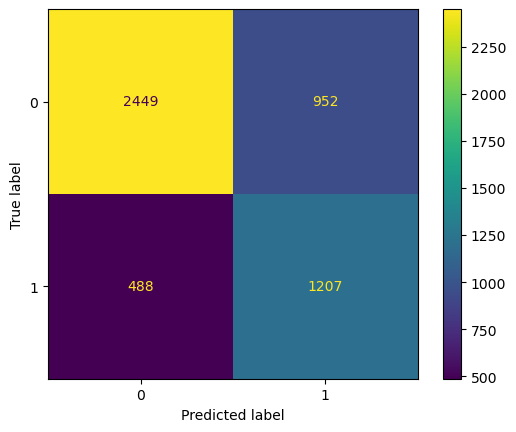

In [58]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(best_model, x_test, y_test)